<a href="https://colab.research.google.com/github/amyas-lab/DL4AI-240166-project/blob/main/Final_project_DL4AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [ ]:
# Task 1: Nasdaq stock prediction

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data Filtering:
Build a model on stickers in the same sector, so that it learn more correlated patterns, hence generalizing better.

Minimum Data points: 120 - 500

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os

my_tickers = ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'INTC', 'SNOW', 'ADBE']
folder_path = '/content/drive/MyDrive/nasdaq_stockprice/nasdaq_stockprice'

# Check the input

for ticker in my_tickers:
    file_name = f"{ticker}.csv"
    file_path = os.path.join(folder_path, file_name)

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        print(f"\n[Stock symbol: {ticker}]")
        print(f"- Number of rows: {len(df)}")


        display(df.head())

        # Check available features
        features = ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']
        missing = [f for f in features if f not in df.columns]
        if not missing:
            print(f">>> Have enough 6 features")
        else:
            print(f">>> Miss {missing}")
    else:
        print(f"\n[!] Not found the path for {ticker} in {file_path}")


[Stock symbol: NVDA]
- Number of rows: 6013


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,22-01-1999,0.388021,0.437500,271468800,0.488281,0.410156,0.376886
1,25-01-1999,0.410156,0.442708,51048000,0.458333,0.453125,0.416370
2,26-01-1999,0.411458,0.458333,34320000,0.467448,0.417969,0.384065
3,27-01-1999,0.395833,0.419271,24436800,0.429688,0.416667,0.382869
4,28-01-1999,0.412760,0.416667,22752000,0.419271,0.415365,0.381673


>>> Have enough 6 features

[Stock symbol: AAPL]
- Number of rows: 10590


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


>>> Have enough 6 features

[Stock symbol: MSFT]
- Number of rows: 9264


...

>>> Have enough 6 features

[Stock symbol: INTC]
- Number of rows: 10778


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,17-03-1980,0.325521,0.325521,10924800,0.330729,0.325521,0.198333
1,18-03-1980,0.322917,0.325521,17068800,0.328125,0.322917,0.196747
2,19-03-1980,0.330729,0.330729,18508800,0.335938,0.330729,0.201507
3,20-03-1980,0.329427,0.330729,11174400,0.334635,0.329427,0.200713
4,21-03-1980,0.317708,0.322917,12172800,0.322917,0.317708,0.193573


>>> Have enough 6 features

[!] Not found the path for SNOW in /content/drive/MyDrive/nasdaq_stockprice/nasdaq_stockprice/SNOW.csv

[Stock symbol: ADBE]
- Number of rows: 9158


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,13-08-1986,0.210938,0.0,18899200,0.218750,0.210938,0.198057
1,14-08-1986,0.222656,0.0,4160000,0.230469,0.222656,0.209060
2,15-08-1986,0.218750,0.0,4332800,0.222656,0.218750,0.205392
3,18-08-1986,0.210938,0.0,2828800,0.218750,0.210938,0.198057
4,19-08-1986,0.214844,0.0,2060800,0.218750,0.214844,0.201725


>>> Have enough 6 features


#### Task 1.1. Multi-feature extension

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.preprocessing import MinMaxScaler

# Scaler: MinMaxScaler
  # Reason: StandardScaler is not compatible with the volatile nature of stock market
  # Expected usage of Tanh (-1, 1) or Sigmoid functions (0,1)

selected_tickers =['NVDA', 'AAPL', 'MSFT', 'AMZN', 'INTC', 'ADBE']
folder_path = '/content/drive/MyDrive/nasdaq_stockprice/nasdaq_stockprice'

def prepare_multi_feature(tickers, seq_length = 60):
  all_X, all_y = [], [] # All_y: predicted label
  # Initialize the scaler
  scaler = MinMaxScaler(feature_range = (0,1)) # Avoid negative values

  for ticker in tickers:
    file_name = f"{ticker}.csv"
    file_path = os.path.join(folder_path, file_name)
    if not os.path.exists(file_path):
      print(f"\n[!] Not found the path for {ticker} in {file_path}")
      continue
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

    features = ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']
    data = df[features].values # Corrected from .value to .values

    # Scale
    scaled_data = scaler.fit_transform(data)

    # Sliding window
    for i in range(len(scaled_data) - seq_length):
              # Slicing
               # Example: at i = 1, all_X takes the values from row 1 to row 61
               # Target y takes the value at row 61x

              all_X.append(scaled_data[i : i + seq_length]) # Input: 60 ngày, 6 features
              all_y.append(scaled_data[i + seq_length, 3])  # Output: Giá Close ngày kế tiếp

  return np.array(all_X), np.array(all_y)

X, y = prepare_multi_feature(selected_tickers)
print("Result of Task 1.1")
print(f"- Shape of X: {X.shape}")
print(f"- Shape of y: {y.shape}")

Result of Task 1.1
- Shape of X: (51881, 60, 6)
- Shape of y: (51881,)


- seq_length = 60. 60 days = transaction ~ 3 months (1 season). The goal is to allow the model to learn the seasonal patterns.


#### Task 1.2. Nasdaq k-th day forecast
- Model in use: LSTM.
- Alternative: CNN with Conv1D.
- Nature: Have short term memory to learn about the correlations among days.
  - Day 60 depends on preceding days.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# First layer of LSTM
model.add(LSTM(units = 50, return_sequences = True, input_shape = (60,6)))
model.add(Dropout(0.2)) # Avoid overfitting

# Second layer of LSTM
model.add(LSTM(units = 50, return_sequences = False))
model.add(Dropout(0.2))

# Dense layer
model.add(Dense(units=25, activation='relu'))

# Output layer for regression problem
model.add(Dense(units=1))

# Compile
model.compile(optimizer='adam', loss='mean_squared_error')
  # MSE as a penalty for regression problem


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Split the data into training, validation and test set

In [ ]:
from sklearn.model_selection import train_test_split

k = 1
window_size = 60
num_features = 6
X_data = np.array(X)
y_data = np.array(y)

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 0.2, shuffle = False)
# In training, 80% for actual training and 20% for validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, shuffle = False)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of X_test: {X_test.shape}")


Shape of X_train: (33203, 60, 6)
Shape of X_val: (8301, 60, 6)
Shape of X_test: (10377, 60, 6)


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    filepath='/content/drive/MyDrive/best_model.keras',
    save_best_only=True, #
    monitor='val_loss',
    mode='min'
)

# Thêm callbacks vào lệnh fit
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint_callback] # <--- Thêm dòng này
)


Epoch 1/50
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 70s 67ms/step - loss: 5.6753e-05 - val_loss: 0.0024
Epoch 2/50
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 75s 60ms/step - loss: 5.9734e-05 - val_loss: 0.0024
Epoch 3/50
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 60s 58ms/step - loss: 6.0555e-05 - val_loss: 0.0026
Epoch 4/50
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 84s 60ms/step - loss: 6.1232e-05 - val_loss: 0.0021
Epoch 5/50
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 81s 59ms/step - loss: 5.7287e-05 - val_loss: 0.0025
Epoch 6/50
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 83s 60ms/step - loss: 6.0201e-05 - val_loss: 0.0025
Epoch 7/50
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 62s 60ms/step - loss: 5.8291e-05 - val_loss: 0.0022
Epoch 8/50
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 81s 59ms/step - loss: 5.6756e-05 - val_loss: 0.0026
Epoch 9/50
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - loss: 5.7983e-05 - val_loss: 0.0023
Epoch 10/50
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 60s 58ms/step - loss: 5.7179e-05 - val_loss: 0.0019
Epoch 11/50
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 60s 58ms/step - 

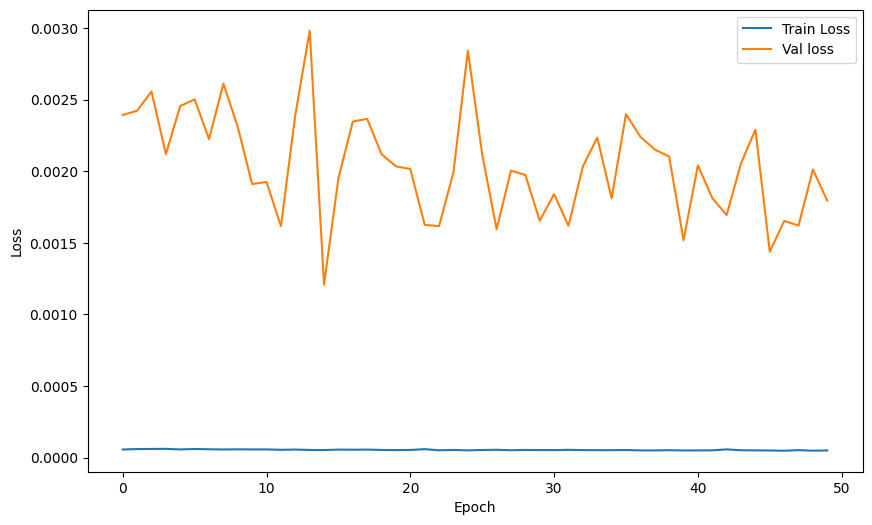

Text(0.5, 1.0, 'Model Loss Progress')

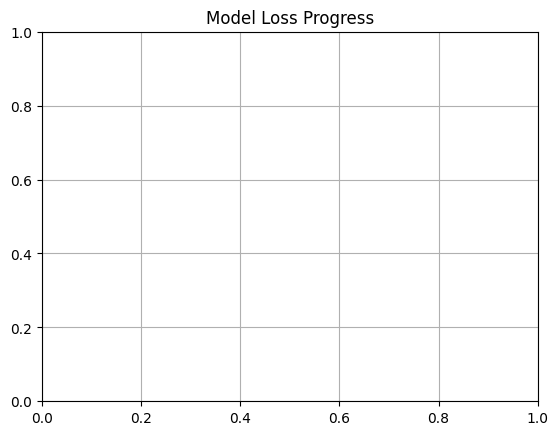

In [ ]:
# Plot the Loss curve of train and validation set
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label = 'Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.grid(True)
plt.title('Model Loss Progress')